# Overview
This notebook provides code to analyze methylation of position 4 (1-indexed) of MYC binding sites (CAC**G**TG) and control sites (nnC**G**TG).

Input files from external sources:
- hg19.fa
- new_refseq_exons_171007.bed
    file of exons to exclude
- GSM5064727_08_GT.sorted.bw
    methylation data from: https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSM5064727
Input files generated by other scripts
- myc_control_sample_{i}_matches_nnCGTG_sampled.bed for i in 1,2..10
    generated when running process_mutation_counts.py

Output files:
- myc_control_sample_{i}_nnCGTG_methylation_values.bed for i in 1,2..10
- myc_control_methylation_values.bed
- myc_methylation_values.bed

Also outputs a chart and MannWhitney U test results in the notebook


In [1]:
! conda install bioconda::ucsc-bigwigtobedgraph -y

Solving environment: done


==> WARNING: A newer version of conda exists. <==
  current version: 4.13.0
  latest version: 24.5.0

Please update conda by running

    $ conda update -n base -c defaults conda



## Package Plan ##

  environment location: /Users/kylepinheiro/opt/anaconda3/envs/wei_paper

  added / updated specs:
    - bioconda::ucsc-bigwigtobedgraph


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2024.7.2   |       hecd8cb5_0         128 KB
    openssl-3.0.14             |       h46256e1_0         4.4 MB
    ------------------------------------------------------------
                                           Total:         4.6 MB

The following packages will be UPDATED:

  ca-certificates                      2024.3.11-hecd8cb5_0 --> 2024.7.2-hecd8cb5_0
  openssl                                 3.0.13-hca72f7f_2 --> 3.0.14-h46256e1_0



ca-certificates-

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from pybedtools import BedTool
import pyBigWig
from scipy.stats import mannwhitneyu
import seaborn as sb

INPUT_PATH = "./input"
OUTPUT_PATH = "./intermediate_and_output"

### Remove broken portion of GSM5064727_08_GT.sorted.bw file. Something in the region of chr1:905988-1014576 causes the file not to be ingested correctly by UCSC tools. If that region is omitted the file seems to be processed without issue.

In [3]:
# to see error:
# ! bigWigToBedGraph ./GSM5064727_08_GT.sorted.bw ./temp.bed

In [4]:
original_bigwig = pyBigWig.open(f"{INPUT_PATH}/GSM5064727_08_GT.sorted.bw")
# all chromosomes are added in their entirety except chr1, for which we retrive all but the problematic region
for chrom in original_bigwig.chroms().keys():
    if chrom == "chr1":
        ! bigWigToBedGraph -chrom=chr1 -end=905988 {INPUT_PATH}/GSM5064727_08_GT.sorted.bw {OUTPUT_PATH}/temp.bed
        ! cat {OUTPUT_PATH}/temp.bed >> {OUTPUT_PATH}/gastric_methylation.bed
        ! bigWigToBedGraph -chrom=chr1 -start=1014596 {INPUT_PATH}/GSM5064727_08_GT.sorted.bw {OUTPUT_PATH}/temp.bed
    else: 
        ! bigWigToBedGraph -chrom={chrom} {INPUT_PATH}/GSM5064727_08_GT.sorted.bw {OUTPUT_PATH}/temp.bed
    
    ! cat {OUTPUT_PATH}/temp.bed >> {OUTPUT_PATH}/gastric_methylation.bed

! rm {OUTPUT_PATH}/temp.bed

# divide all regions in methylation data to single-nucleotide regions
! bedtools makewindows -b {OUTPUT_PATH}/gastric_methylation.bed -w 1 -i src > {OUTPUT_PATH}/gastric_methylation_individ.bed

In [13]:
# find matches for CACGTG and nnCGTG
! python fastaRegexFinder.py --fasta  {INPUT_PATH}/hg19.fa --regex "(?=(CACGTG))" > {OUTPUT_PATH}/cacgtg_matches.bed
! python fastaRegexFinder.py --fasta  {INPUT_PATH}/hg19.fa --regex "(?=([CAGT]((?<!C)A|[CGT])CGTG))" > {OUTPUT_PATH}/nncgtg_matches.bed

exons = BedTool(f"{INPUT_PATH}/new_refseq_exons_171007.bed")

for prefix in ["cacgtg", "nncgtg"]:
    # subtract motif matches that are in exons
    matches_no_exons = BedTool(f"{OUTPUT_PATH}/{prefix}_matches.bed").intersect(exons, v=True, output=f"{OUTPUT_PATH}/{prefix}_matches_no_exons.bed")

Processing chr1
Processing chr2
Processing chr3
Processing chr4
Processing chr5
Processing chr6
Processing chr7
Processing chrX
Processing chr8
Processing chr9
Processing chr10
Processing chr11
Processing chr12
Processing chr13
Processing chr14
Processing chr15
Processing chr16
Processing chr17
Processing chr18
Processing chr20
Processing chrY
Processing chr19
Processing chr22
Processing chr21
Processing chr6_ssto_hap7
Processing chr6_mcf_hap5
Processing chr6_cox_hap2
Processing chr6_mann_hap4
Processing chr6_apd_hap1
Processing chr6_qbl_hap6
Processing chr6_dbb_hap3
Processing chr17_ctg5_hap1
Processing chr4_ctg9_hap1
Processing chr1_gl000192_random
Processing chrUn_gl000225
Processing chr4_gl000194_random
Processing chr4_gl000193_random
Processing chr9_gl000200_random
Processing chrUn_gl000222
Processing chrUn_gl000212
Processing chr7_gl000195_random
Processing chrUn_gl000223
Processing chrUn_gl000224
Processing chrUn_gl000219
Processing chr17_gl000205_random
Processing chrUn_gl00021

In [14]:
# intersect methylation bedfile with cacgtg matches
methylation = BedTool(f"{OUTPUT_PATH}/gastric_methylation_individ.bed")
methylation.intersect(BedTool(f"{OUTPUT_PATH}/cacgtg_matches_no_exons.bed"), wa=True, wb=True, output=f"{OUTPUT_PATH}/cacgtg_methylated_matches.bed")

<BedTool(./intermediate_and_output/cacgtg_methylated_matches.bed)>

In [7]:
# intersect methylation bedfile with each sample set of nncgtg sites
for i in range(1, 11):
    print(i)
    # the files "myc_control_sample_{i}_matches_nnCGTG_sampled.bed" are created when process_mutation_counts_w_sampling.py is run
    methylation.intersect(BedTool(f"{OUTPUT_PATH}/myc_control_sample_{i}_matches_nnCGTG_sampled.bed"), wa=True, wb=True, output=f"{OUTPUT_PATH}/myc_control_sample_{i}_nnCGTG_methylated_matches.bed")


1
2
3
4
5
6
7
8
9
10


In [15]:
# for analysis of overall nncgtg dataset (not sampled)
methylation.intersect(BedTool(f"{OUTPUT_PATH}/nncgtg_matches_no_exons.bed"), wa=True, wb=True, output=f"{OUTPUT_PATH}/nncgtg_methylated_matches.bed")

<BedTool(./intermediate_and_output/nncgtg_methylated_matches.bed)>

## Now I need to filter this down to the 4th (one-indexed) position of each motif.

In [9]:
def process_methylated_matches(prefix):
    """From the file of overlaps between methylation data and MYC or control sites,
    further filter to retrieve specifically the methylation values for position 4 (1-indexed).
    """
    filename = f"{OUTPUT_PATH}/{prefix}_methylated_matches.bed"
    df = pd.read_csv(filename, sep="\t", header=None)
    df = df.drop(columns=[1, 4, 7, 8])
    # set position of methylation relative to position of MYC/control site match
    # Note: the position column is 1-indexed
    df["position"] = df[2] - df[5]
    # for '-' strand matches, adjust position to be relative to reading from 5' to 3'
    df.loc[df[9] == "-", "position"] = df[6] - df[2] + 1
    
    # keep only those methylation values that are at position 4 of the MYC/control site
    df = df[df["position"] == 4]  # Note again: the values in the position column are 1-indexed
    
    print(f"num methylated positions: {len(df)}")
    
    # output a bedfile of all the methylation values for the positions of interest for this set of sites
    df = df.drop(columns=["position"])
    df.to_csv(f"{OUTPUT_PATH}/{prefix}_methylation_values.bed", sep="\t", index=False, header=None)
    
    return df[3]

In [10]:
def get_statistics(nncgtg_values, cacgtg_values):
    """Output summary statistics and generate a file for use in plotting or further statistical tests.
    """
    print(mannwhitneyu(cacgtg_values, nncgtg_values, alternative="less"))
    print(f"summary:")
    print(nncgtg_values.describe())
    
    new_df = pd.concat([pd.DataFrame({"value": nncgtg_values, "group": "nncgtg"}), pd.DataFrame({"value": cacgtg_values, "group": "cacgtg"})])
    
    print(new_df.groupby("group")["value"].describe())
    
    return new_df

In [11]:
def plot(new_df):
    """Takes a dataframe with two columns 'group' ('nncgtg' or 'cacgtg') and 'value' (0 to 100) and outputs paired boxplots. Each boxplot corresponds to a group.
    Eg. 
        value   column
        83.333  nncgtg
        100.00  nncgtg
        50.00   cacgtg
        0.00    cacgtg
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    # Create the boxplot on the subplot
    sb.boxplot(data=new_df, x="group", y="value", ax=ax)

    # Customize the plot
    ax.set_title("Methylation distributions of Myc sites and control sites (at position 4)")
    ax.set_ylabel("Methylation level")
    
    # Display the plot
    plt.show()

num methylated positions: 230126
1
num methylated positions: 226802
MannwhitneyuResult(statistic=19440888807.0, pvalue=0.0)
summary:
count    226802.000000
mean         70.484692
std          32.047806
min           0.000000
25%          50.000000
50%          83.333300
75%         100.000000
max         100.000000
Name: 3, dtype: float64
           count       mean        std  min      25%      50%       75%    max
group                                                                         
cacgtg  230126.0  56.452994  33.703092  0.0  25.7143  60.0000   86.6667  100.0
nncgtg  226802.0  70.484692  32.047806  0.0  50.0000  83.3333  100.0000  100.0
2
num methylated positions: 226709
MannwhitneyuResult(statistic=19424224787.0, pvalue=0.0)
summary:
count    226709.000000
mean         70.499398
std          32.054744
min           0.000000
25%          50.000000
50%          83.333300
75%         100.000000
max         100.000000
Name: 3, dtype: float64
           count       mean        

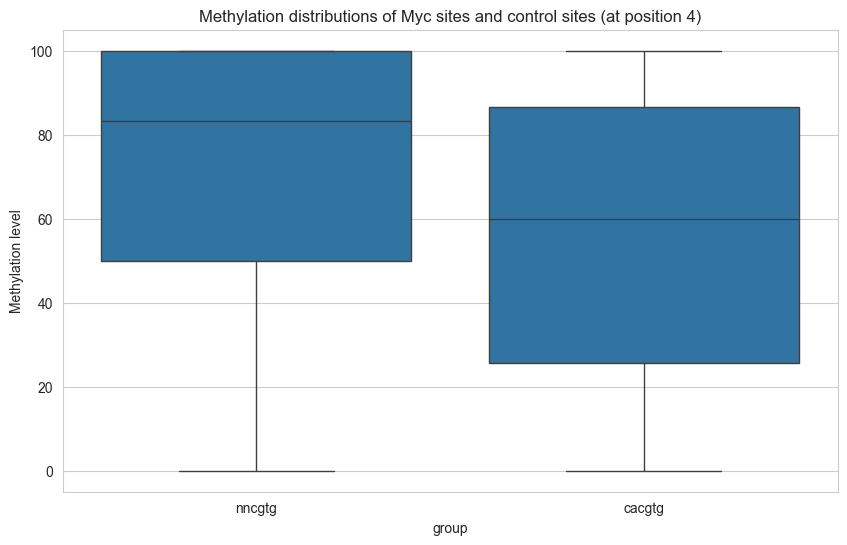

In [16]:
# retrieve methylation values for CACGTG sites, for use in comparing to various controls.
cacgtg_methylation_vals = process_methylated_matches("cacgtg")

# for each sample set of nncgtg sites, retrieve methylation value of position 4
# also compute the mannwhitneyu test, print summary statistics
for i in range(1, 11):
    print(i)
    nncgtg_methylation_vals = process_methylated_matches(f"myc_control_sample_{i}_nnCGTG")
    new_df = get_statistics(nncgtg_methylation_vals, cacgtg_methylation_vals)

# record all similar methylation data for the whole nncgtg dataset (instead of a sample of them)
nncgtg_methylation_vals = process_methylated_matches("nncgtg")
new_df = get_statistics(nncgtg_methylation_vals, cacgtg_methylation_vals)
plot(new_df)